# Module 10 Lab - Unsupervised Learning

**Objective:** To understand and apply two common **unsupervised learning** techniques: **K-Means Clustering** for finding groups in data and **Principal Component Analysis (PCA)** for dimensionality reduction.

**In this lab, you will write the code to perform clustering and PCA, and you will interpret the results.**

## Part 1: Supervised vs. Unsupervised Learning

So far, every model we have built has been a **supervised learning** model. This means we had **labeled data**—we had both the features (X) and the correct answer, or target (y). The goal was to learn a mapping from X to y.

In **unsupervised learning**, we only have the features (X). There is **no target variable**. The goal is to discover interesting structures or patterns hidden in the data on its own.

Two major types of unsupervised learning are:
*   **Clustering:** Automatically grouping similar data points together.
*   **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering

**Concept:** K-Means is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:
1.  Randomly placing `k` centroids (the center of a cluster) in the data.
2.  **Assignment Step:** Assigning each data point to its nearest centroid.
3.  **Update Step:** Moving each centroid to the average position of all the points assigned to it.
4.  Repeating steps 2 and 3 until the centroids stop moving.

**Problem:** We will use a synthetic dataset of customer spending habits to segment them into groups.

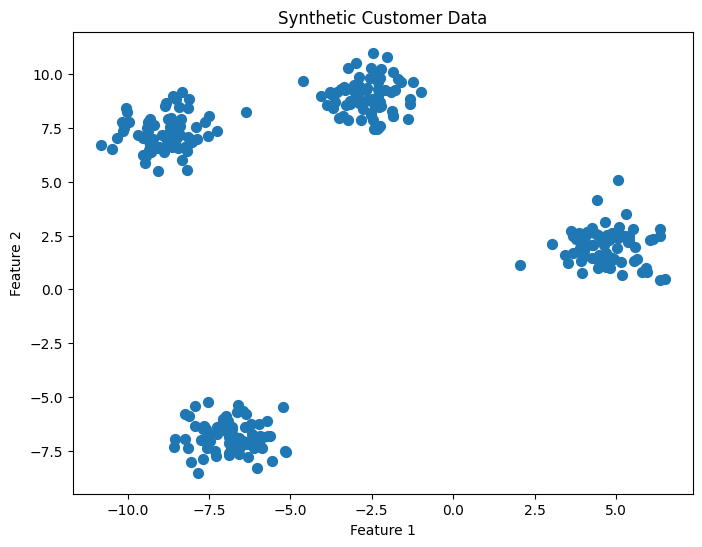

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Customer Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)

**Concept:** How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.

**Your Task:** Calculate and plot the inertia for `k` values from 1 to 10.

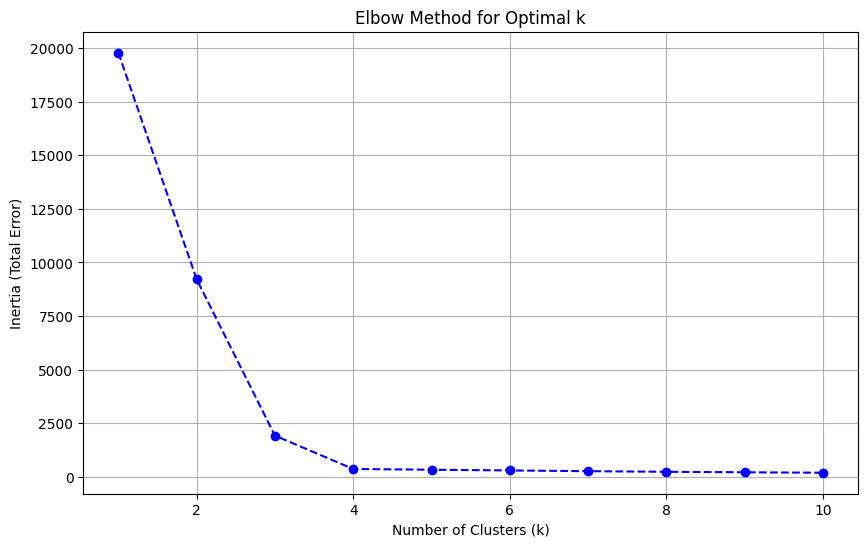

In [2]:
from sklearn.cluster import KMeans

# --- Task 1: Find the Optimal k ---

# 1. Create an empty list to store the inertia values
inertia = []

# 2. Loop through k values from 1 to 10
for k in range(1, 11):
    # 3. Create and fit a KMeans model with `n_clusters=k`
    # n_init=10 ensures the algorithm runs multiple times to find the best starting points
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # 4. Append the model's inertia_ to your list
    inertia.append(kmeans.inertia_)

# 5. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Total Error)')
plt.grid(True)
plt.show()

### Task 2: Perform K-Means Clustering and Visualize

From the elbow plot, it looks like `k=4` is the optimal number of clusters.

**Your Task:** Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

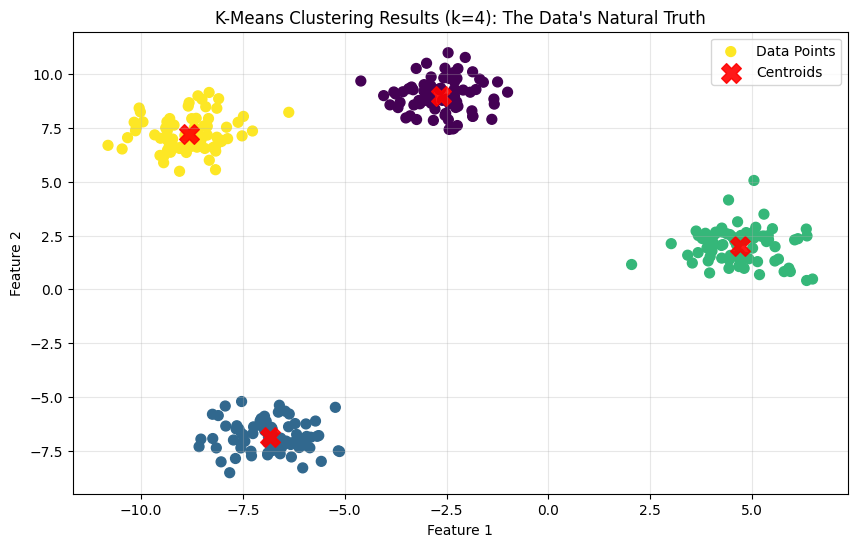

In [3]:
# --- Task 2: Perform K-Means Clustering and Visualize ---

# 1. Create and fit a KMeans model with n_clusters=4
# n_init=10 runs the algorithm 10 times with different random starts to find the best result.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

# 2. Get the cluster assignments (labels) for each data point
labels = kmeans.labels_

# 3. Get the coordinates of the cluster centers (centroids)
centers = kmeans.cluster_centers_

# 4. Create a scatter plot of the data, colored by the labels
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis', label='Data Points')

# Plot the centers as large red 'X' marks
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.9, marker='X', label='Centroids')

plt.title('K-Means Clustering Results (k=4): The Data\'s Natural Truth')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Principal Component Analysis (PCA)

**Concept:** PCA is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.

**Use Cases:**
*   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.
*   **Performance:** Speeding up model training by using fewer features.

**Problem:** We will use the Iris dataset, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset

**Your Task:** Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

Explained variance by component: [0.92461872 0.05306648]
Total variance explained by 2 components: 97.77%


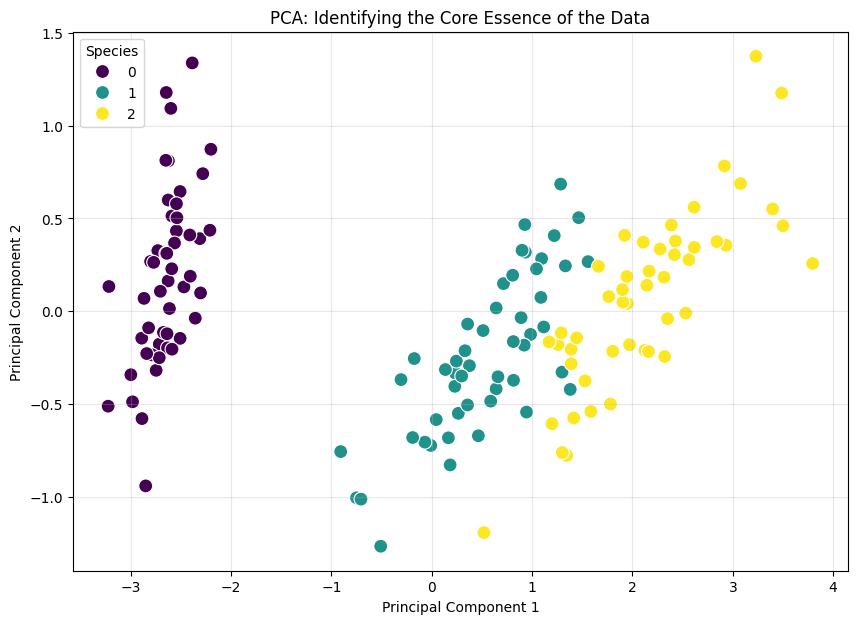

In [5]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data properly
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# 2. Create a PCA instance to reduce to 2 components
pca = PCA(n_components=2)

# 3. Fit PCA to the data and transform it
X_pca = pca.fit_transform(X_iris)

# 4. Print the explained variance ratio
# This shows how much of the original "information" we kept.
print(f"Explained variance by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# 5. Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=["Principal Component 1", "Principal Component 2"])
pca_df["Species"] = y_iris

# 6. Plot the results
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Principal Component 1", y="Principal Component 2", 
                hue="Species", data=pca_df, palette='viridis', s=100)
plt.title('PCA: Identifying the Core Essence of the Data')
plt.grid(True, alpha=0.3)
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the fundamental difference between supervised and unsupervised learning?**
The primary difference lies in the presence of labels. Supervised learning involves training a model on a dataset where the target output is already known, allowing the model to learn a specific "narrative" or mapping from inputs to provided results. In contrast, unsupervised learning works with unlabeled data, requiring the algorithm to find its own hidden patterns, structures, or groupings without being told what the "correct" answer is. While supervised learning can be influenced by how facts are presented in a given dataset, unsupervised learning acts as an independent "truth checker" by analyzing the raw mathematical relationships within the data.
2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**
Choosing the largest possible $k$ (where $k$ equals the number of data points) would indeed reduce inertia to zero, but it would result in extreme overfitting. At that point, the model has simply "memorized" the location of every individual point rather than finding meaningful clusters or generalizations. The "elbow" represents the optimal balance where the model is complex enough to capture the true underlying groups but simple enough to remain useful and interpretable for real-world applications.
3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**
This high percentage indicates that there is significant redundancy among the original four features. It tells us that the core "essence" or truth of the data can be captured in just two dimensions with less than a 5% loss of information. This proves that we can reduce the complexity of the dataset significantly—moving from a 4D space to a 2D plane—while still maintaining a highly accurate representation of the relationships between the different samples.
